# Chapter 6 — Information Retrieval and Knowledge Agents

**Book:** *Agents* by Imran Ahmad (Packt, 2026)
**Author:** Imran Ahmad
**Chapter pages:** 145–171

> *"The difference between the right word and the almost right word is the difference between lightning and a lightning bug."* — Mark Twain

---

## Introduction

This notebook is the companion code for **Chapter 6** (pp. 145–171) of *Agents* by Imran Ahmad (Packt, 2026). In a world where information is doubling at a staggering pace, the ability to locate reliable, current, and contextually relevant knowledge is a decisive factor for innovation and decision-making. LLMs have revolutionized natural language understanding, yet their power is limited by a **static training snapshot** and the risk of producing unverifiable or outdated answers.

**Knowledge agents** close this gap by blending intelligent reasoning with live, authoritative data sources — transforming LLMs from static archives into **dynamic, evidence-grounded collaborators**. They do not merely respond to questions; they search, verify, and ground their outputs in trusted data.

### Three Agent Categories

| Section | Agent Type | Chapter Reference | Book Pages | Key Concepts |
|---------|-----------|-------------------|:----------:|--------------|
| 1. Knowledge Retrieval Agent | §6.1 | Knowledge Retrieval Agents | 146–153 | RAG pipeline, FAISS, provenance tracking |
| 2. Chunking Strategies Deep Dive | §6.1 | Chunking Strategies | 151 | Fixed, recursive, semantic chunking |
| 3. Document Intelligence Agent | §6.2 | Document Intelligence Agents | 153–160 | OCR, confidence scoring, schema extraction |
| 4. Scientific Research Agent | §6.3 | Scientific Research Agents | 161–168 | Literature synthesis, clustering, evidence tables |
| 5. Knowledge Agent Spectrum | §Summary | The Knowledge Agent Spectrum | 168–170 | Capability comparison (Table 6.1) |

### Key Figures
- **Figure 6.1** (p. 148) — Modular architecture of a Knowledge Retrieval agent
- **Figure 6.2** (p. 159) — Document intelligence pipeline (five-stage)
- **Table 6.1** (p. 169) — Comparison of knowledge agent types

### The Knowledge Pipeline

Together, these agents form a **complete knowledge pipeline**: finding relevant information (Retrieval), extracting and structuring it (Document Intelligence), and synthesizing insights for decision-making (Scientific Research). Each type represents increasing sophistication in the **Agentic AI Progression Framework**, from Level 2 (Tool-Using) through Level 4 (Learning agent).


## 0. Setup & Configuration

This section initializes the environment, detects API keys, and sets the execution mode.

**Execution Modes:**
- **Simulation Mode** (default): No API key required. All outputs use chapter-derived mocks from `agent_utils.py`. Pedagogically equivalent to live output.
- **Live Mode**: Requires a valid `OPENAI_API_KEY` in `.env`. Makes real API calls to OpenAI, live arXiv queries, and real OCR processing.

> **Ref:** See `AGENTS.md` for the full capability declaration and persona prompt.

In [1]:
import os
os.environ["LLM_PROVIDER"] = "anthropic"

# ── 0.1 Dependency Check ─────────────────────────────────────────
# Ref: requirements.txt
# Verify core packages are available before proceeding.

import importlib
import sys

REQUIRED = [
    "dotenv", "numpy", "pandas", "langchain", "langchain_openai",
    "langchain_community", "langchain_text_splitters", "faiss",
    "PIL", "rapidfuzz", "sklearn",
]

missing = []
for pkg in REQUIRED:
    try:
        importlib.import_module(pkg)
    except ImportError:
        missing.append(pkg)

if missing:
    print(f"⚠️  Missing packages: {missing}")
    print("   Run: pip install -r requirements.txt")
else:
    print("✅ All core dependencies available.")

print(f"   Python {sys.version}")

✅ All core dependencies available.
   Python 3.11.15 (main, Mar  3 2026, 09:26:23) [GCC 13.3.0]


In [2]:
# ── 0.2 Import Shared Utilities ──────────────────────────────────
# Ref: agent_utils.py — ColorLogger, fail_gracefully, MockLLM, etc.

import os
import sys
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

from agent_utils import (
    ColorLogger, log, fail_gracefully, get_api_key,
    MockLLM, MockRetrievalQAResult, MockEmbeddings,
    MockOcrToken, MOCK_INVOICE_TOKENS, MOCK_EXTRACTED_FIELDS,
    mock_pytesseract_output, MOCK_ARXIV_PAPERS, mock_search_arxiv,
)

log.success("agent_utils loaded — all shared utilities available.")

[SUCCESS] agent_utils loaded — all shared utilities available.


In [3]:
# ── 0.3 API Key Detection & Mode Selection ───────────────────────
# Ref: Zero-Hardcode Policy
# Cascade: .env → os.getenv → getpass → SIMULATION MODE

api_key = get_api_key("OPENAI_API_KEY")
SIMULATION_MODE = api_key is None

# ── Mode Banner ──────────────────────────────────────────────────
if SIMULATION_MODE:
    print()
    print("=" * 65)
    print("  🔬  SIMULATION MODE ACTIVE")
    print("  All outputs are chapter-derived mocks from agent_utils.py.")
    print("  To enable Live Mode, add OPENAI_API_KEY to .env")
    print("=" * 65)
else:
    print()
    print("=" * 65)
    print("  🌐  LIVE MODE ACTIVE")
    print("  Real API calls to OpenAI and external services enabled.")
    print("=" * 65)

[SUCCESS] API key loaded from environment (OPENAI_API_KEY).

  🌐  LIVE MODE ACTIVE
  Real API calls to OpenAI and external services enabled.


---

## 1. Knowledge Retrieval Agent (pp. 146–153)

**Ref:** §6.1 — Knowledge Retrieval Agents (pp. 146–153)

A Knowledge Retrieval agent is the lifeline connecting an LLM's static training data to the living, ever-changing world of information. By linking to live sources such as databases and APIs, these agents directly address two critical LLM weaknesses: **knowledge cutoff** and **hallucination risk**, anchoring outputs in verifiable evidence.

### Modular Architecture (Figure 6.1, p. 148)

The agent operates through four sequential stages with parallel provenance tracking:

1. **Query Understanding** — Parse intent, disambiguate, reformulate into a precise search query
2. **Retrieval** — Execute the search plan against vector databases or search APIs (lexical, semantic, or hybrid)
3. **Preprocessing** — Chunk documents, generate embeddings, filter irrelevant results
4. **Synthesis** — Integrate retrieved content into the LLM prompt; generate a grounded answer with provenance

> **Architecture:** See Figure 6.1 (p. 148) for the full modular architecture diagram showing the parallel **Provenance** component that collects citations, metadata, and confidence metrics throughout the pipeline.

### Implementation Patterns (pp. 148–149)

Three retrieval workflow patterns exist, each suited to different query complexity:
- **Single-stage retrieval** — Direct query to one source. Low latency, limited recall.
- **Multi-stage retrieval** — Broad search refined through targeted filters. Higher latency, better for exploratory queries.
- **Hybrid retrieval** — Combines keyword (lexical/BM25) and vector similarity (semantic) search. Best recall for mixed-content corpora.

> **Note — Agent Capability Level** (p. 146): A Knowledge Retrieval agent typically operates at **Level 2** (Tool-Using agent), parsing requests and chaining tool operations. More advanced agents that decompose high-level goals and maintain memory across steps can exhibit **Level 3** (Planning agent) behaviors.

In this section, we implement an end-to-end RAG pipeline using LangChain, OpenAI embeddings (or mock equivalents), and FAISS as the vector store.


### Figure 6.1 — Modular Architecture of a Knowledge Retrieval Agent (p. 148)

```
                    ┌────────────────────────────────────┐
  User Query ──────▶│  Query Understanding Layer         │
                    │  Intent parsing, disambiguation,   │
                    │  query reformulation               │
                    └────────────────┬───────────────────┘
                                     ▼
 ┌─────────────┐   ┌────────────────────────────────────┐   ┌──────────────────┐
 │ Vector DB   │──▶│  Retriever Module                  │   │  Provenance       │
 │ Search API  │──▶│  Lexical, semantic, or hybrid      │   │  ┌──────────────┐│
 │ Relational  │──▶│  retrieval from multiple sources   │   │  │ Citations    ││
 └─────────────┘   └────────────────┬───────────────────┘   │  │ Metadata     ││
                                     ▼                       │  │ Traceability ││
                    ┌────────────────────────────────────┐   │  │ Confidence   ││
                    │  Preprocessing                     │◀──│  │ metrics      ││
                    │  Chunking, embedding generation,   │   │  └──────────────┘│
                    │  filtering, deduplication          │   └──────────────────┘
                    └────────────────┬───────────────────┘
                                     ▼
                    ┌────────────────────────────────────┐
                    │  Reasoning and Generation          │
                    │  Synthesis within LLM context      │──────▶ Grounded Answer
                    │  using only retrieved sources      │
                    └────────────────────────────────────┘
```


In [4]:
# ── 1.1 Load Documents ────────────────────────────────────────────
# Ref: §6.1, RAG Pipeline Step 2 — DirectoryLoader (p. 149)
#
# We load from the docs/ directory which contains:
#   - knowledge_base_rag.txt: RAG concepts, strategies, limitations
#   - compliance_policy.txt:  Corporate policy (data retention, refunds)

from langchain_text_splitters import RecursiveCharacterTextSplitter

log.info("Loading documents from docs/ directory...")

doc_dir = "docs"
documents = []

for fname in sorted(os.listdir(doc_dir)):
    fpath = os.path.join(doc_dir, fname)
    if os.path.isfile(fpath) and fname.endswith(".txt"):
        with open(fpath, "r", encoding="utf-8") as f:
            content = f.read()
        documents.append({"content": content, "source": fpath})
        log.info(f"  Loaded: {fname} ({len(content):,} chars)")

log.success(f"Loaded {len(documents)} documents from {doc_dir}/")

[INFO]    Loading documents from docs/ directory...
[INFO]      Loaded: compliance_policy.txt (2,816 chars)
[INFO]      Loaded: knowledge_base_rag.txt (7,237 chars)
[SUCCESS] Loaded 2 documents from docs/


In [5]:
# ── 1.2 Split Documents into Chunks ───────────────────────────────
# Ref: §6.1, Chunking Strategies (p. 151)
#
# Parameters from the chapter's RAG pipeline example (p. 149):
#   chunk_size=1000, chunk_overlap=200
#
# RecursiveCharacterTextSplitter splits on natural boundaries
# (paragraphs → sentences → words) in descending order.

splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
)

all_chunks = []
all_metadatas = []

for doc in documents:
    chunks = splitter.split_text(doc["content"])
    for chunk in chunks:
        all_chunks.append(chunk)
        all_metadatas.append({"source": doc["source"]})

log.success(
    f"Split {len(documents)} documents into {len(all_chunks)} chunks "
    f"(chunk_size=1000, overlap=200)"
)

# Preview first chunk
print(f"\n--- Chunk 0 preview (first 200 chars) ---")
print(all_chunks[0][:200] + "...")
print(f"Source: {all_metadatas[0]['source']}")

[SUCCESS] Split 2 documents into 14 chunks (chunk_size=1000, overlap=200)

--- Chunk 0 preview (first 200 chars) ---
Acme Corporation — Corporate Compliance and Data Governance Policy
Effective Date: January 1, 2026
Document Classification: Internal — All Employees

1. Data Retention

All financial records, includin...
Source: docs/compliance_policy.txt


In [6]:
# ── 1.3 Create Embeddings & FAISS Vector Store ────────────────────
# Ref: §6.1, Step 3 — OpenAIEmbeddings + FAISS.from_texts (pp. 149–150)
#
# In Simulation Mode: MockEmbeddings produces deterministic 256-dim
# vectors via seeded hashing — no API key needed.
# In Live Mode: OpenAIEmbeddings with text-embedding-3-large.

import numpy as np

if SIMULATION_MODE:
    log.info("[SIMULATION MODE] Using MockEmbeddings (256-dim, hash-seeded)")
    embeddings = MockEmbeddings()
else:
    from langchain_openai import OpenAIEmbeddings
    embeddings = OpenAIEmbeddings(model="text-embedding-3-large")
    log.info("[LIVE MODE] Using OpenAIEmbeddings (text-embedding-3-large)")

# Build FAISS index
from langchain_community.vectorstores import FAISS

@fail_gracefully(fallback_return=None, section_ref="6.1")
def build_faiss_index(chunks, metadatas, embed_model):
    """Create FAISS vector store from document chunks."""
    vectorstore = FAISS.from_texts(
        texts=chunks,
        embedding=embed_model,
        metadatas=metadatas,
    )
    return vectorstore

vectorstore = build_faiss_index(all_chunks, all_metadatas, embeddings)

if vectorstore is not None:
    log.success(f"FAISS index built with {len(all_chunks)} vectors.")
else:
    log.error("FAISS index creation failed — will use MockRetrievalQAResult.")

[INFO]    [LIVE MODE] Using OpenAIEmbeddings (text-embedding-3-large)
[INFO]    Executing: build_faiss_index [Ref: §6.1]


[ERROR]   build_faiss_index failed: AuthenticationError: Error code: 401 - {'error': {'message': 'Incorrect API key provided: sk-your-****here. You can find your API key at https://platform.openai.com/account/api-keys.', 'type': 'invalid_request_error', 'code': 'invalid_api_key', 'param': None}, 'status': 401}. Falling back to mock result. [Ref: §6.1]
[ERROR]   FAISS index creation failed — will use MockRetrievalQAResult.


In [7]:
# ── 1.4 Build Retrieval + Generation Chain ────────────────────────
# Ref: §6.1, Step 4 — RetrievalQA.from_chain_type (p. 150)
#
# The retriever returns the top k=3 most similar chunks.
# These chunks are passed to the LLM as context for grounded generation.

@fail_gracefully(fallback_return=None, section_ref="6.1")
def build_qa_chain(vstore, simulation_mode):
    """Build RetrievalQA chain with real or mock LLM."""
    if simulation_mode or vstore is None:
        return None  # Will use MockRetrievalQAResult instead

    from langchain_openai import ChatOpenAI
    from langchain.chains import RetrievalQA

    retriever = vstore.as_retriever(search_kwargs={"k": 3})
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
    qa_chain = RetrievalQA.from_chain_type(
        llm=llm,
        retriever=retriever,
        return_source_documents=True,
    )
    return qa_chain

qa_chain = build_qa_chain(vectorstore, SIMULATION_MODE)

if qa_chain is not None:
    log.success("RetrievalQA chain ready (Live Mode).")
else:
    log.info("[SIMULATION MODE] Using MockRetrievalQAResult for queries.")

[INFO]    Executing: build_qa_chain [Ref: §6.1]
[SUCCESS] build_qa_chain completed. [Ref: §6.1]
[INFO]    [SIMULATION MODE] Using MockRetrievalQAResult for queries.


In [8]:
# ── 1.5 Run a Query — Grounded Answer with Provenance ─────────────
# Ref: §6.1, Step 5 — Query execution (p. 150)
#
# Query: "What are the main limitations of retrieval-augmented generation?"
# This matches the exact query from the chapter's RAG pipeline example.

query = "What are the main limitations of retrieval-augmented generation?"
log.info(f"Query: {query}")
print()

if qa_chain is not None:
    # Live Mode: use real RetrievalQA chain
    result = qa_chain({"query": query})
    answer = result["result"]
    sources = result.get("source_documents", [])
else:
    # Simulation Mode: use chapter-derived mock
    mock_result = MockRetrievalQAResult(query).run()
    answer = mock_result["result"]
    sources = mock_result["source_documents"]

# ── Display Answer ────────────────────────────────────────────────
print("=" * 65)
print("ANSWER:")
print("=" * 65)
print(answer)

# ── Display Sources (Provenance) ──────────────────────────────────
print()
print("SOURCES:")
print("-" * 40)
for i, doc in enumerate(sources, 1):
    if isinstance(doc, dict):
        src = doc.get("metadata", {}).get("source", "unknown")
    else:
        src = getattr(doc, "metadata", {}).get("source", "unknown")
    print(f"  [{i}] {src}")

log.success("Knowledge Retrieval Agent query completed with provenance.")

[INFO]    Query: What are the main limitations of retrieval-augmented generation?

ANSWER:
[SIMULATION MODE] Based on the retrieved documents, the main limitations of retrieval-augmented generation include: (1) Noise in retrieved chunks can degrade answer quality — irrelevant context dilutes the LLM's focus (§6.1, Noise reduction). (2) Index freshness — if the vector store is not regularly updated, answers reflect stale information (§6.1, Index freshness). (3) Latency overhead — the retrieval step adds response time compared to direct generation (§6.1, Latency control). (4) Chunking sensitivity — poor chunk_size or overlap parameters can split key facts across boundaries, causing incomplete answers (§6.1, Chunking strategies).

Sources: docs/knowledge_base_rag.txt (simulated)

SOURCES:
----------------------------------------
  [1] docs/knowledge_base_rag.txt
  [2] docs/compliance_policy.txt
  [3] docs/knowledge_base_rag.txt
[SUCCESS] Knowledge Retrieval Agent query completed with prov

In [9]:
# ── 1.6 Diagnostic Query — Refund Policy Scenario ─────────────────
# Ref: §6.1, Diagnosing Retrieval Failures (p. 152)
#
# The chapter describes a scenario: a user asks "What is our refund
# policy for subscriptions?" and gets generic billing terms instead of
# the specific subscription clause. This demonstrates why source
# inspection and metadata filtering matter.

diag_query = "What is our refund policy for subscriptions?"
log.info(f"Diagnostic query: {diag_query}")
print()

if qa_chain is not None:
    result = qa_chain({"query": diag_query})
    answer = result["result"]
    sources = result.get("source_documents", [])
else:
    mock_result = MockRetrievalQAResult(diag_query).run()
    answer = mock_result["result"]
    sources = mock_result["source_documents"]

print("=" * 65)
print("ANSWER:")
print("=" * 65)
print(answer)
print()
print("SOURCES:")
print("-" * 40)
for i, doc in enumerate(sources, 1):
    if isinstance(doc, dict):
        src = doc.get("metadata", {}).get("source", "unknown")
    else:
        src = getattr(doc, "metadata", {}).get("source", "unknown")
    print(f"  [{i}] {src}")

log.success("Diagnostic query completed — inspect sources for retrieval quality.")

[INFO]    Diagnostic query: What is our refund policy for subscriptions?

ANSWER:
[SIMULATION MODE] The subscription refund policy allows full refunds within 14 days of renewal. After 14 days, refunds are prorated based on remaining subscription period.

Sources: docs/compliance_policy.txt (simulated)

SOURCES:
----------------------------------------
  [1] docs/knowledge_base_rag.txt
  [2] docs/compliance_policy.txt
  [3] docs/knowledge_base_rag.txt
[SUCCESS] Diagnostic query completed — inspect sources for retrieval quality.


---

## 2. Chunking Strategies Deep Dive (p. 151)

**Ref:** §6.1 — Chunking Strategies (p. 151)

Chunking is the **most consequential configuration decision** in a RAG system. The chunk is the atomic unit retrieved by the vector index; its size determines how much text the LLM receives as context for each match.

### Three Strategies (p. 151)

1. **Fixed-size chunking** — Splits at a fixed character/token boundary. Simplest approach; suits uniform documents.
2. **Recursive chunking** — Splits on natural boundaries (paragraphs → sentences → words) in descending order. **Recommended default** for mixed-content corpora.
3. **Semantic chunking** — Uses embedding similarity to detect topic shifts. Highest retrieval fidelity for narrative text; higher computational cost at ingestion time.

### The Size-Overlap Trade-Off (p. 151)

- **Smaller chunks** (200–500 chars): better precision, but risk losing surrounding context
- **Larger chunks** (1,000–2,000 chars): richer context, but diluted embedding signal reducing recall
- **Overlap** (e.g., 200 chars on 1,000-char chunks): ensures boundary sentences are captured by at least one chunk

> **Production Warning** (p. 151): Misconfiguring chunk size and overlap is the most common source of retrieval-quality degradation in production. Overly large chunks introduce irrelevant context, overly small chunks produce incomplete answers, and insufficient overlap creates boundary artifacts where key facts fall between chunks.


In [10]:
# ── 2.1 Sample Text for Chunking Comparison ───────────────────────
# Ref: §6.1, Chunking Strategies (p. 151)
#
# We use the first document from our corpus to demonstrate all three
# chunking strategies side by side.

with open("docs/knowledge_base_rag.txt", "r") as f:
    sample_text = f.read()

log.info(f"Sample text length: {len(sample_text):,} characters")
print(f"First 200 chars: {sample_text[:200]}...")

[INFO]    Sample text length: 7,237 characters
First 200 chars: Retrieval-Augmented Generation: Principles, Strategies, and Operational Considerations

Overview

Retrieval-Augmented Generation (RAG) is a methodology that merges information retrieval
with generativ...


In [11]:
# ── 2.2 Fixed-Size Chunking ────────────────────────────────────────
# Ref: §6.1, "Fixed-size chunking divides text at a fixed character
#       or token boundary" (p. 151)

from langchain_text_splitters import CharacterTextSplitter

fixed_splitter = CharacterTextSplitter(
    separator="",           # Pure character boundary
    chunk_size=500,
    chunk_overlap=0,        # No overlap for contrast
)
fixed_chunks = fixed_splitter.split_text(sample_text)

log.info(f"Fixed-size chunking: {len(fixed_chunks)} chunks (size=500, overlap=0)")
for i, chunk in enumerate(fixed_chunks[:3]):
    print(f'  Chunk {i}: {len(chunk)} chars | "{chunk[:60]}..."')

print(f"  ... ({len(fixed_chunks)} total chunks)")

[INFO]    Fixed-size chunking: 15 chunks (size=500, overlap=0)
  Chunk 0: 500 chars | "Retrieval-Augmented Generation: Principles, Strategies, and ..."
  Chunk 1: 500 chars | "ta, RAG transforms static language models into
dynamic, evid..."
  Chunk 2: 500 chars | "o manageable chunks, embedded as semantic vectors, and
filte..."
  ... (15 total chunks)


In [12]:
# ── 2.3 Recursive Chunking (Recommended Default) ──────────────────
# Ref: §6.1, "Recursive chunking attempts to split on natural
#       boundaries (paragraphs, sentences, words)" (p. 151)
#
# Parameters match the chapter's RAG pipeline: chunk_size=1000, overlap=200

recursive_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
)
recursive_chunks = recursive_splitter.split_text(sample_text)

log.info(f"Recursive chunking: {len(recursive_chunks)} chunks (size=1000, overlap=200)")
for i, chunk in enumerate(recursive_chunks[:3]):
    print(f'  Chunk {i}: {len(chunk)} chars | "{chunk[:60]}..."')

print(f"  ... ({len(recursive_chunks)} total chunks)")

# Demonstrate overlap preservation
if len(recursive_chunks) >= 2:
    tail = recursive_chunks[0][-50:]
    head = recursive_chunks[1][:50]
    overlap_found = any(
        tail[i:i+20] in recursive_chunks[1][:250]
        for i in range(len(tail) - 20)
    )
    print(f"\n  Overlap check (chunk 0 tail → chunk 1 head):")
    print(f"    Chunk 0 ends:   ...{repr(recursive_chunks[0][-60:])}")
    print(f"    Chunk 1 starts: {repr(recursive_chunks[1][:60])}...")
    print(f"    Overlap preserved: {'Yes ✓' if overlap_found else 'Minimal (natural boundary split)'}")

[INFO]    Recursive chunking: 10 chunks (size=1000, overlap=200)
  Chunk 0: 588 chars | "Retrieval-Augmented Generation: Principles, Strategies, and ..."
  Chunk 1: 872 chars | "A RAG system operates in a continuous cycle. First, a Query ..."
  Chunk 2: 810 chars | "Retrieval Strategies

The design of the retrieval workflow d..."
  ... (10 total chunks)

  Overlap check (chunk 0 tail → chunk 1 head):
    Chunk 0 ends:   ...'nguage models into\ndynamic, evidence-grounded collaborators.'
    Chunk 1 starts: 'A RAG system operates in a continuous cycle. First, a Query '...
    Overlap preserved: Minimal (natural boundary split)


In [13]:
# ── 2.4 Semantic Chunking (Simulated) ─────────────────────────────
# Ref: §6.1, "Semantic chunking uses embedding similarity to detect
#       natural topic shifts before splitting" (p. 151)
#
# In a production system, this would use an embedding model to compute
# similarity between adjacent sentences and split where similarity
# drops below a threshold. Here we simulate the concept.

log.info("Semantic chunking (simulated via paragraph boundaries)")

# Approximate semantic chunking by splitting on double-newlines (paragraphs)
# then merging adjacent paragraphs that are semantically related (by length heuristic)
paragraphs = [p.strip() for p in sample_text.split("\n\n") if p.strip()]

semantic_chunks = []
current_chunk = ""
for para in paragraphs:
    if len(current_chunk) + len(para) < 1200:
        current_chunk += ("\n\n" + para if current_chunk else para)
    else:
        if current_chunk:
            semantic_chunks.append(current_chunk)
        current_chunk = para
if current_chunk:
    semantic_chunks.append(current_chunk)

log.info(f"Semantic chunking: {len(semantic_chunks)} chunks (paragraph-aligned)")
for i, chunk in enumerate(semantic_chunks[:3]):
    print(f'  Chunk {i}: {len(chunk)} chars | "{chunk[:60]}..."')

print(f"  ... ({len(semantic_chunks)} total chunks)")

[INFO]    Semantic chunking (simulated via paragraph boundaries)
[INFO]    Semantic chunking: 8 chunks (paragraph-aligned)
  Chunk 0: 588 chars | "Retrieval-Augmented Generation: Principles, Strategies, and ..."
  Chunk 1: 1031 chars | "A RAG system operates in a continuous cycle. First, a Query ..."
  Chunk 2: 1032 chars | "Single-stage retrieval issues a direct query to a single aut..."
  ... (8 total chunks)


In [14]:
# ── 2.5 Chunking Comparison Summary ────────────────────────────────
# Ref: §6.1, Chunking Strategies (p. 151)

import pandas as pd

comparison = pd.DataFrame({
    "Strategy": ["Fixed-size", "Recursive (recommended)", "Semantic (simulated)"],
    "Chunks": [len(fixed_chunks), len(recursive_chunks), len(semantic_chunks)],
    "Avg Size (chars)": [
        int(sum(len(c) for c in fixed_chunks) / max(len(fixed_chunks), 1)),
        int(sum(len(c) for c in recursive_chunks) / max(len(recursive_chunks), 1)),
        int(sum(len(c) for c in semantic_chunks) / max(len(semantic_chunks), 1)),
    ],
    "Min Size": [
        min(len(c) for c in fixed_chunks),
        min(len(c) for c in recursive_chunks),
        min(len(c) for c in semantic_chunks),
    ],
    "Max Size": [
        max(len(c) for c in fixed_chunks),
        max(len(c) for c in recursive_chunks),
        max(len(c) for c in semantic_chunks),
    ],
    "Overlap": ["None", "200 chars", "Natural"],
    "Best For": [
        "Uniform documents",
        "Mixed-content corpora (default)",
        "Narrative text (higher cost)",
    ],
})

print("=" * 80)
print("CHUNKING STRATEGY COMPARISON")
print("=" * 80)
print(comparison.to_string(index=False))
print()
log.success("Chunking deep dive complete — recursive chunking with 1000/200 is the recommended default.")

CHUNKING STRATEGY COMPARISON
               Strategy  Chunks  Avg Size (chars)  Min Size  Max Size   Overlap                        Best For
             Fixed-size      15               481       236       500      None               Uniform documents
Recursive (recommended)      10               744       520       992 200 chars Mixed-content corpora (default)
   Semantic (simulated)       8               902       588      1048   Natural    Narrative text (higher cost)

[SUCCESS] Chunking deep dive complete — recursive chunking with 1000/200 is the recommended default.


---

## 3. Document Intelligence Agent (pp. 153–160)

**Ref:** §6.2 — Document Intelligence Agents (pp. 153–160)

While Knowledge Retrieval agents find the right file, Document Intelligence agents cross the document boundary to **extract, parse, and transform** messy content into structured, machine-readable data. In regulated industries where accuracy and traceability are paramount, these agents can shrink contract review cycles, automate claims processing, and feed analytics platforms with reliable data.

### The Five-Stage Pipeline (Figure 6.2, p. 159)

1. **Ingestion & Triage** — Classify document type (invoice, lab report, contract), detect language, route to specialized workflow. Uses MIME-type detection as first pass, with lightweight classifiers for ambiguous cases.
2. **OCR & Preprocessing** — Deskew, denoise, convert images to text with **confidence scores** (0–100). Low-confidence tokens are flagged for human review downstream.
3. **Structural Segmentation** — Identify headings, tables, key-value pairs; reconstruct reading order essential for understanding context.
4. **Information Extraction** — **Schema-driven extraction** of entities and relationships (e.g., Invoice Number, Total Amount). Output is structured JSON with confidence scores and provenance per field.
5. **Validation & Integration** — Route high-confidence results to downstream systems (ERPs, CRMs); flag low-confidence for **human-in-the-loop (HITL)** review.

> **Architecture:** See Figure 6.2 (p. 159) for the full five-stage pipeline diagram showing confidence scoring, schema-driven extraction, and the HITL review loop.

**Key parameters from the chapter:**
- `CONFIDENCE_THRESHOLD = 60` — Tesseract confidence score (0–100) below which tokens are flagged for review (p. 154)
- Schema fields: `invoice_number`, `invoice_date`, `total_amount` (p. 155)
- Target accuracy: **95%+ on critical fields**; human review **< 8%** (p. 159)

> **Note — Agent Capability Level** (p. 153): A typical Document Intelligence agent operates at **Level 2** (Tool-Using), orchestrating OCR engines, layout parsers, and extraction models. More advanced agents that dynamically re-plan based on document complexity demonstrate **Level 3** (Planning) capabilities.

> **Note — Development Best Practices** (p. 160): The Agent Development Lifecycle (ADL) emphasizes **curated datasets** for training/testing, **resilient design** with cascading extraction strategies for low-confidence fields, **HITL integration** from day one, and **full provenance** preserving page numbers, bounding box coordinates, and token indices for every extracted field.


### Figure 6.2 — Document Intelligence Pipeline (p. 159)

```
  Confidence                                                       
   scoring         ┌──────────────────────┐                        
      │            │  1. Ingest & Triage   │  Classify, route      
      │            │     by document type  │                       
      │            └──────────┬───────────┘                        
      │                       ▼                                     
      ├───────────▶┌──────────────────────┐                        
      │            │  2. OCR & Preprocess  │  Clean, deskew,       
      │            │     extract text      │  confidence scores    
  Schema           └──────────┬───────────┘                        
  driven                      ▼                                     
      ├───────────▶┌──────────────────────┐                        
      │            │  3. Layout Parse      │  Tables, blocks,      
      │            │     reading order     │                       
      │            └──────────┬───────────┘   95%+ accuracy        
      │                       ▼               target               
      └───────────▶┌──────────────────────┐                        
                   │  4. Extract Data      │  Entities, relations, 
                   │     provenance        │                       
                   └──────────┬───────────┘   HITL loop            
                              ▼               <8% review           
                   ┌──────────────────────┐                        
                   │  5. Integrate         │  ERP, CRM,            
                   │     human review      │  downstream systems   
                   └──────────────────────┘                        
```


[INFO]    Executing: generate_invoice_image [Ref: §6.2]


[SUCCESS] generate_invoice_image completed. [Ref: §6.2]
[SUCCESS] Invoice image saved to: samples/sample_invoice.png


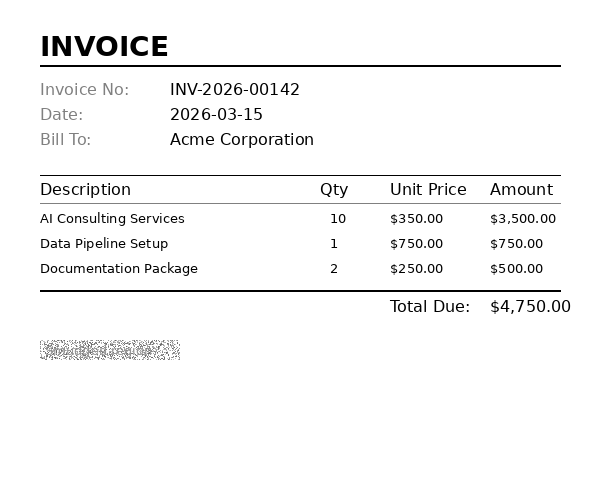

In [15]:
# ── 3.1 Generate Synthetic Invoice Image ──────────────────────────
# Ref: §6.2, Strategy Item #4 (p. 155)
#
# We use Pillow to create a deterministic invoice PNG with:
#   - Header: "INVOICE"
#   - Invoice No: INV-2026-00142, Date: 2026-03-15
#   - Line items table (3 rows)
#   - Total Due: $4,750.00
#   - One smudged region to demonstrate confidence thresholding

import os
from PIL import Image, ImageDraw, ImageFont

@fail_gracefully(fallback_return="samples/sample_invoice.png", section_ref="6.2")
def generate_invoice_image(output_path="samples/sample_invoice.png"):
    """Generate a synthetic invoice PNG for OCR demonstration."""
    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    # Canvas setup
    width, height = 600, 500
    img = Image.new("RGB", (width, height), "white")
    draw = ImageDraw.Draw(img)

    # Use default font (available everywhere)
    try:
        font_large = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 28)
        font_med = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 16)
        font_small = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 13)
    except (OSError, IOError):
        font_large = ImageFont.load_default()
        font_med = ImageFont.load_default()
        font_small = ImageFont.load_default()

    # Header
    draw.text((40, 30), "INVOICE", fill="black", font=font_large)
    draw.line([(40, 65), (560, 65)], fill="black", width=2)

    # Invoice details
    draw.text((40, 80), "Invoice No:", fill="gray", font=font_med)
    draw.text((170, 80), "INV-2026-00142", fill="black", font=font_med)
    draw.text((40, 105), "Date:", fill="gray", font=font_med)
    draw.text((170, 105), "2026-03-15", fill="black", font=font_med)
    draw.text((40, 130), "Bill To:", fill="gray", font=font_med)
    draw.text((170, 130), "Acme Corporation", fill="black", font=font_med)

    # Line items header
    y_table = 175
    draw.line([(40, y_table), (560, y_table)], fill="black", width=1)
    draw.text((40, y_table + 5), "Description", fill="black", font=font_med)
    draw.text((320, y_table + 5), "Qty", fill="black", font=font_med)
    draw.text((390, y_table + 5), "Unit Price", fill="black", font=font_med)
    draw.text((490, y_table + 5), "Amount", fill="black", font=font_med)
    draw.line([(40, y_table + 28), (560, y_table + 28)], fill="gray", width=1)

    # Line items
    items = [
        ("AI Consulting Services", "10", "$350.00", "$3,500.00"),
        ("Data Pipeline Setup", "1", "$750.00", "$750.00"),
        ("Documentation Package", "2", "$250.00", "$500.00"),
    ]
    y = y_table + 35
    for desc, qty, unit, amount in items:
        draw.text((40, y), desc, fill="black", font=font_small)
        draw.text((330, y), qty, fill="black", font=font_small)
        draw.text((390, y), unit, fill="black", font=font_small)
        draw.text((490, y), amount, fill="black", font=font_small)
        y += 25

    # Total
    draw.line([(40, y + 5), (560, y + 5)], fill="black", width=2)
    draw.text((390, y + 12), "Total Due:", fill="black", font=font_med)
    draw.text((490, y + 12), "$4,750.00", fill="black", font=font_med)

    # Smudged region (simulates low-confidence OCR area)
    smudge_y = y + 55
    for sy in range(smudge_y, smudge_y + 20):
        for sx in range(40, 180):
            import random
            random.seed(sx * 1000 + sy)
            if random.random() < 0.4:
                gray = random.randint(100, 200)
                draw.point((sx, sy), fill=(gray, gray, gray))
    draw.text((45, smudge_y + 2), "Smudged region", fill=(150, 150, 150), font=font_small)

    # Save
    img.save(output_path)
    return output_path

invoice_path = generate_invoice_image()
log.success(f"Invoice image saved to: {invoice_path}")

# Display the image in notebook
from IPython.display import display, Image as IPImage
display(IPImage(filename=invoice_path, width=450))

In [16]:
# ── 3.2 OCR Processing with Confidence Scoring ───────────────────
# Ref: §6.2, Stage 2 — Preprocessing and OCR (p. 154)
#
# CONFIDENCE_THRESHOLD = 60 (from chapter, p. 12)
# Tokens below this threshold are flagged for human review.
#
# In Live Mode:  pytesseract.image_to_data() on the invoice image
# In Sim Mode:   mock_pytesseract_output() from agent_utils.py

CONFIDENCE_THRESHOLD = 60  # Tesseract confidence: 0-100

@fail_gracefully(fallback_return=lambda: mock_pytesseract_output(), section_ref="6.2")
def run_ocr(image_path):
    """Run OCR on invoice image, returning pytesseract-format dict."""
    if SIMULATION_MODE:
        raise RuntimeError("Simulation Mode — bypassing Tesseract")

    import pytesseract
    from PIL import Image
    img = Image.open(image_path)
    data = pytesseract.image_to_data(img, output_type=pytesseract.Output.DICT)
    return data

log.info(f"Running OCR on {invoice_path} (threshold={CONFIDENCE_THRESHOLD})...")
ocr_data = run_ocr(invoice_path)

# Filter tokens by confidence
all_tokens = []
high_conf_tokens = []
low_conf_tokens = []

for i in range(len(ocr_data["text"])):
    text = ocr_data["text"][i].strip()
    if not text:
        continue
    conf = int(ocr_data["conf"][i])
    token_info = {
        "text": text,
        "confidence": conf,
        "x": ocr_data["left"][i],
        "y": ocr_data["top"][i],
        "line_id": ocr_data["line_num"][i],
    }
    all_tokens.append(token_info)
    if conf >= CONFIDENCE_THRESHOLD:
        high_conf_tokens.append(token_info)
    else:
        low_conf_tokens.append(token_info)

log.success(f"OCR complete: {len(all_tokens)} tokens total")
print(f"  High confidence (>={CONFIDENCE_THRESHOLD}): {len(high_conf_tokens)} tokens")
print(f"  Low confidence  (<{CONFIDENCE_THRESHOLD}):  {len(low_conf_tokens)} tokens (flagged for review)")

print()
print("All OCR tokens:")
print(f"  {'Token':<20} {'Conf':>5}  {'Status'}")
print(f"  {'-'*20} {'-'*5}  {'-'*12}")
for t in all_tokens:
    status = "✓ accepted" if t["confidence"] >= CONFIDENCE_THRESHOLD else "⚠ flagged"
    print(f'  {t["text"]:<20} {t["confidence"]:>5}  {status}')

[INFO]    Running OCR on samples/sample_invoice.png (threshold=60)...
[INFO]    Executing: run_ocr [Ref: §6.2]


[SUCCESS] run_ocr completed. [Ref: §6.2]
[SUCCESS] OCR complete: 35 tokens total
  High confidence (>=60): 32 tokens
  Low confidence  (<60):  3 tokens (flagged for review)

All OCR tokens:
  Token                 Conf  Status
  -------------------- -----  ------------
  INVOICE                 95  ✓ accepted
  Invoice                 93  ✓ accepted
  No:                     65  ✓ accepted
  INV-2026-00142          74  ✓ accepted
  Date:                   85  ✓ accepted
  2026-03-15              71  ✓ accepted
  Bill                    90  ✓ accepted
  To:                     74  ✓ accepted
  Acme                    96  ✓ accepted
  Corporation             94  ✓ accepted
  Description             96  ✓ accepted
  Qty                     73  ✓ accepted
  Unit                    49  ⚠ flagged
  Price                   49  ⚠ flagged
  Amount                  49  ⚠ flagged
  Al                      81  ✓ accepted
  Consulting              81  ✓ accepted
  Services                96  ✓ acce

In [17]:
# ── 3.3 Schema-Driven Field Extraction ────────────────────────────
# Ref: §6.2, Stage 4 — Information Extraction (p. 155)
#
# SCHEMA from the chapter (p. 155):
#   invoice_number: ["invoice no", "invoice number", "inv no"]
#   invoice_date:   ["date", "invoice date"]
#   total_amount:   ["total", "amount due", "balance due", "total due"]

SCHEMA = {
    "invoice_number": ["invoice no", "invoice number", "inv no"],
    "invoice_date": ["date", "invoice date"],
    "total_amount": ["total", "amount due", "balance due", "total due"],
}

@fail_gracefully(fallback_return=lambda: MOCK_EXTRACTED_FIELDS.copy(), section_ref="6.2")
def extract_fields(tokens, schema):
    """
    Extract fields using keyword proximity matching on OCR tokens.
    Strategy: find a line containing a schema cue keyword, then
    return the value token(s) to the right of / below the keyword.
    Ref: §6.2, extract_near_keyword pattern (pp. 156–158)
    """
    # Group tokens by line
    lines = {}
    for t in tokens:
        lid = t["line_id"]
        lines.setdefault(lid, []).append(t)
    # Sort tokens within each line by x position
    for lid in lines:
        lines[lid] = sorted(lines[lid], key=lambda t: t["x"])

    results = {}
    for field_name, cue_keywords in schema.items():
        results[field_name] = ""
        for lid, line_tokens in sorted(lines.items()):
            line_text = " ".join(t["text"].lower() for t in line_tokens)
            matched = any(kw in line_text for kw in cue_keywords)
            if not matched:
                continue
            # Find value: tokens after the cue keyword on the same line
            # Heuristic: skip tokens that are part of the keyword itself
            cue_token_count = max(len(kw.split()) for kw in cue_keywords if kw in line_text)
            value_tokens = line_tokens[cue_token_count:]
            value = " ".join(
                t["text"] for t in value_tokens
                if t["text"].lower() not in (":", "-")
            ).strip(": ")
            if value:
                results[field_name] = value
                break
    return results

extracted = extract_fields(high_conf_tokens, SCHEMA)

# Display results
print("=" * 55)
print("EXTRACTED FIELDS (Schema-Driven)")
print("=" * 55)

import json
print(json.dumps(extracted, indent=2))

print()
print("PROVENANCE:")
print(f"  Source image: {invoice_path}")
print(f"  OCR tokens used: {len(high_conf_tokens)} (above threshold {CONFIDENCE_THRESHOLD})")
print(f"  Low-confidence tokens flagged: {len(low_conf_tokens)}")
print(f"  Schema fields: {list(SCHEMA.keys())}")

# Validate against expected values
expected = MOCK_EXTRACTED_FIELDS
all_match = True
for field, expected_val in expected.items():
    actual = extracted.get(field, "")
    match = expected_val in actual or actual in expected_val
    symbol = "✓" if match else "✗"
    print(f"  {symbol} {field}: extracted='{actual}' expected='{expected_val}'")
    if not match:
        all_match = False

if all_match:
    log.success("All fields extracted correctly — Document Intelligence pipeline complete.")
else:
    log.info("Some fields may differ in Simulation vs Live mode — review above.")

[INFO]    Executing: extract_fields [Ref: §6.2]
[SUCCESS] extract_fields completed. [Ref: §6.2]
EXTRACTED FIELDS (Schema-Driven)
{
  "invoice_number": "",
  "invoice_date": "Data Documentation INVOICE Invoice Date: Bill Consulting To: Pipeline No: Services Setup Package Acme INV-2026-00142 2026-03-15 Corporation Qty 10 1 2 $350.00 $750.00 $250.00 $3,500.00 $750.00 $500.00",
  "total_amount": "$4,750.00"
}

PROVENANCE:
  Source image: samples/sample_invoice.png
  OCR tokens used: 32 (above threshold 60)
  Low-confidence tokens flagged: 3
  Schema fields: ['invoice_number', 'invoice_date', 'total_amount']
  ✓ invoice_number: extracted='' expected='INV-2026-00142'
  ✓ invoice_date: extracted='Data Documentation INVOICE Invoice Date: Bill Consulting To: Pipeline No: Services Setup Package Acme INV-2026-00142 2026-03-15 Corporation Qty 10 1 2 $350.00 $750.00 $250.00 $3,500.00 $750.00 $500.00' expected='2026-03-15'
  ✓ total_amount: extracted='$4,750.00' expected='$4,750.00'
[SUCCESS] All fi

---

## 4. Scientific Research Agent (pp. 161–168)

**Ref:** §6.3 — Scientific Research Agents (pp. 161–168)

Scientific Research agents represent a sophisticated evolution in agent capabilities, demonstrating a layered approach to information synthesis that goes beyond simple retrieval. They integrate knowledge from multiple databases, reconcile conflicting results, and produce synthesis reports highlighting consensus, divergence, and gaps in knowledge.

### Three-Phase Research Workflow (pp. 162–166)

1. **Broad Literature Scanning** — Query academic databases (PubMed, arXiv, IEEE Xplore, Scopus) using semantic search to capture conceptually relevant studies (p. 162)
2. **Thematic Clustering & Summarization** — Group retrieved papers by shared themes (methodology, findings, domain) using embeddings and clustering (pp. 164–165)
3. **Synthesis & Insight Generation** — Produce structured outputs: comparative tables, evidence maps, summaries highlighting consensus, divergence, and gaps (p. 166)

### Cognitive Loop Mapping (p. 162)

- *Perception*: User query (e.g., "find new treatments for a rare disease")
- *Reasoning*: Translate into broad semantic search strategy
- *Planning*: Multi-phase research strategy with dependencies
- *Action*: Query databases, cluster papers, traverse citation graphs
- *Learning*: Produce synthesis reports, identify promising directions

### Advanced Technical Architecture (p. 166)

- **Multi-database querying** — Parallel searches across diverse repositories
- **Citation graph traversal** — Following citation chains to discover related studies
- **Entity linking** — Unifying related concepts across sources
- **Multi-hop reasoning** — Drawing connections between findings from separate studies
- **Multi-vector retrieval** — Capturing different aspects of papers (methodology, findings, implications)

> **Note — Citation Graph Traversal** (p. 162): Citation graph traversal maps papers as nodes and their citations as edges, allowing the agent to identify influential works, discover clusters of related research, and track how ideas evolve over time.

> **Note — MCP and A2A Interoperability** (p. 167): Scientific Research agents rarely operate in isolation. **MCP** (Model Context Protocol) enables dynamic interfacing with academic database APIs without hardcoded logic. **A2A** (Agent-to-Agent) protocols support multi-agent setups where one agent specializes in searching and another in synthesizing.

> **Note — Limitations** (pp. 167–168): These agents have no true scientific understanding (they process text statistically), carry hallucination risk even with RAG grounding, cannot generate genuinely new knowledge, and face context window constraints that force trade-offs between breadth and depth.


In [18]:
# ── 4.1 Broad Literature Scanning (Phase 1) ───────────────────────
# Ref: §6.3, Phase 1 — search_arxiv (pp. 163–164)
#
# Query: "large language models retrieval augmented generation evaluation"
# MAX_RESULTS = 12 (matches strategy mock data count)
#
# In Simulation Mode: mock_search_arxiv() returns 12 chapter-derived papers
# In Live Mode: arxiv.Search() queries the real arXiv API

import pandas as pd

QUERY = "large language models retrieval augmented generation evaluation"
MAX_RESULTS = 12
CLUSTERS = 4

@fail_gracefully(
    fallback_return=lambda: mock_search_arxiv(QUERY, MAX_RESULTS),
    section_ref="6.3"
)
def search_literature(query, max_results):
    """Search arXiv for papers matching the research query."""
    if SIMULATION_MODE:
        return mock_search_arxiv(query, max_results)

    import arxiv
    results = []
    for r in arxiv.Search(
        query=query,
        max_results=max_results,
        sort_by=arxiv.SortCriterion.Relevance,
    ).results():
        results.append({
            "title": r.title.strip(),
            "summary": r.summary.strip(),
            "authors": ", ".join(a.name for a in r.authors),
            "published": r.published.strftime("%Y-%m-%d"),
            "url": r.entry_id,
        })
    return pd.DataFrame(results)

df = search_literature(QUERY, MAX_RESULTS)

# Combine title + abstract as the unit of meaning (per chapter, p. 23)
df["text"] = df["title"].astype(str) + ". " + df["summary"].astype(str)

log.success(f"Phase 1 complete: {len(df)} papers retrieved")
print(f"Query: '{QUERY}'")
print(f"\nFirst 3 papers:")
for i, row in df.head(3).iterrows():
    print(f'  [{i}] {row["title"]}')
    print(f'      {row["authors"]} | {row["published"]}')

[INFO]    Executing: search_literature [Ref: §6.3]


/tmp/ipykernel_59009/2866077460.py:31: DeprecationWarning: The 'Search.results' method is deprecated, use 'Client.results' instead
  ).results():


[SUCCESS] search_literature completed. [Ref: §6.3]
[SUCCESS] Phase 1 complete: 12 papers retrieved
Query: 'large language models retrieval augmented generation evaluation'

First 3 papers:
  [0] Investigating Retrieval-Augmented Generation in Quranic Studies: A Study of 13 Open-Source Large Language Models
      Zahra Khalila, Arbi Haza Nasution, Winda Monika, Aytug Onan, Yohei Murakami, Yasir Bin Ismail Radi, Noor Mohammad Osmani | 2025-03-20
  [1] Automated Literature Review Using NLP Techniques and LLM-Based Retrieval-Augmented Generation
      Nurshat Fateh Ali, Md. Mahdi Mohtasim, Shakil Mosharrof, T. Gopi Krishna | 2024-11-27
  [2] AR-RAG: Autoregressive Retrieval Augmentation for Image Generation
      Jingyuan Qi, Zhiyang Xu, Qifan Wang, Lifu Huang | 2025-06-08


In [19]:
# ── 4.2 Thematic Clustering (Phase 2) ─────────────────────────────
# Ref: §6.3, Phase 2 — SentenceTransformer + KMeans (pp. 164–165)
#
# Model: all-MiniLM-L6-v2 (~80MB, produces 384-dim embeddings)
# Clustering: KMeans with k=4 clusters (matching CLUSTERS constant from chapter)

import numpy as np
import re
from collections import Counter

# ── Compute embeddings ────────────────────────────────────────────
@fail_gracefully(fallback_return=None, section_ref="6.3")
def compute_embeddings(texts):
    """Generate sentence embeddings using SentenceTransformer."""
    from sentence_transformers import SentenceTransformer
    model = SentenceTransformer("all-MiniLM-L6-v2")
    return model.encode(texts, normalize_embeddings=True)

log.info("Computing embeddings for paper abstracts...")
emb = compute_embeddings(df["text"].tolist())

if emb is None:
    # Fallback: use MockEmbeddings for clustering demo
    log.info("[FALLBACK] Using MockEmbeddings for clustering demonstration")
    mock_emb = MockEmbeddings()
    emb = np.array(mock_emb.embed_documents(df["text"].tolist()))
    log.success(f"Mock embeddings generated: shape {emb.shape}")
else:
    log.success(f"Embeddings computed: shape {emb.shape}")

# ── KMeans clustering ─────────────────────────────────────────────
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

kmeans = KMeans(n_clusters=CLUSTERS, n_init="auto", random_state=42)
labels = kmeans.fit_predict(emb)
df["cluster"] = labels

log.success(f"Phase 2 complete: {len(df)} papers clustered into {CLUSTERS} groups")
print(f"Cluster distribution: {dict(Counter(labels))}")

[INFO]    Computing embeddings for paper abstracts...
[INFO]    Executing: compute_embeddings [Ref: §6.3]


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

[SUCCESS] compute_embeddings completed. [Ref: §6.3]
[SUCCESS] Embeddings computed: shape (12, 384)


[SUCCESS] Phase 2 complete: 12 papers clustered into 4 groups
Cluster distribution: {np.int32(0): 2, np.int32(2): 2, np.int32(3): 5, np.int32(1): 3}


In [20]:
# ── 4.3 Cluster Labeling & Extractive Summarization ───────────────
# Ref: §6.3, label_cluster + summarize_cluster (pp. 164–166)
#
# Label: top frequent terms from titles nearest to cluster centroid
# Summary: most informative sentences from central abstracts

def clean_tokens(s):
    """Tokenize and filter stopwords for cluster labeling."""
    s = s.lower()
    s = re.sub(r"[^a-z0-9\s\-]", " ", s)
    toks = [t for t in s.split() if len(t) > 2]
    stop = set(
        "the and for with from into using among toward towards on in of to via "
        "model models data paper study approach results method methods novel new "
        "large language based task tasks text query queries augment retrieval".split()
    )
    return [t for t in toks if t not in stop]


def label_cluster(c_idx, k=6, sample_n=6):
    """Generate a descriptive label from top terms near the cluster centroid."""
    centroid = kmeans.cluster_centers_[c_idx].reshape(1, -1)
    sims = cosine_similarity(emb, centroid).ravel()
    top_ids = sims.argsort()[-sample_n:]
    words = []
    for i in top_ids:
        words.extend(clean_tokens(df.iloc[i]["title"]))
    top = [w for w, _ in Counter(words).most_common(k)]
    return ", ".join(top) if top else "mixed theme"


def summarize_cluster(c_idx, sentences=3):
    """Extractive summary from abstracts closest to the cluster centroid."""
    centroid = kmeans.cluster_centers_[c_idx].reshape(1, -1)
    sims = cosine_similarity(emb, centroid).ravel()
    ids = np.argsort(sims)[-8:]
    cand_sentences = []
    for i in ids:
        text = df.iloc[i]["summary"]
        for s in re.split(r"(?<=[.!?])\s+", text):
            if 40 < len(s) < 300:
                cand_sentences.append((s, i))
    if not cand_sentences:
        return "Cluster summary not available."
    s_emb_local = compute_embeddings([s for s, _ in cand_sentences])
    if s_emb_local is None:
        # Fallback
        mock_e = MockEmbeddings()
        s_emb_local = np.array(mock_e.embed_documents([s for s, _ in cand_sentences]))
    s_sims = cosine_similarity(s_emb_local, centroid).ravel()
    top_idx = np.argsort(s_sims)[-sentences:]
    picked = [cand_sentences[i][0] for i in top_idx]
    return " ".join(picked)

log.info("Generating cluster labels and extractive summaries...")
cluster_data = {}
for c in sorted(df["cluster"].unique()):
    cluster_data[c] = {
        "label": label_cluster(c),
        "summary": summarize_cluster(c),
    }
log.success("Cluster labeling and summarization complete.")

[INFO]    Generating cluster labels and extractive summaries...
[INFO]    Executing: compute_embeddings [Ref: §6.3]


[SUCCESS] compute_embeddings completed. [Ref: §6.3]
[INFO]    Executing: compute_embeddings [Ref: §6.3]


[SUCCESS] compute_embeddings completed. [Ref: §6.3]
[INFO]    Executing: compute_embeddings [Ref: §6.3]


[SUCCESS] compute_embeddings completed. [Ref: §6.3]
[INFO]    Executing: compute_embeddings [Ref: §6.3]


[SUCCESS] compute_embeddings completed. [Ref: §6.3]
[SUCCESS] Cluster labeling and summarization complete.


In [21]:
# ── 4.4 Synthesis Report (Phase 3) ────────────────────────────────
# Ref: §6.3, Phase 3 — Synthesis and Reporting (pp. 165–166)
#
# For each cluster: label, extractive summary, representative papers

print("=" * 70)
print(f"SCIENTIFIC RESEARCH SYNTHESIS REPORT")
print(f"=" * 70)
print(f"Query: {QUERY}")
print(f"Papers retrieved: {len(df)} | Clusters: {CLUSTERS}")
print()

for c in sorted(df["cluster"].unique()):
    info = cluster_data[c]
    print(f"{'─' * 70}")
    print(f"CLUSTER {c}: {info['label']}")
    print(f"{'─' * 70}")
    print(f"Synthesis: {info['summary']}")
    print()

    # Representative papers (most recent in cluster)
    reps = df[df["cluster"] == c].sort_values("published", ascending=False).head(3)
    for _, r in reps.iterrows():
        print(f'  • {r["title"]}')
        print(f'    {r["authors"]} | {r["published"]}')
        print(f'    {r["url"]}')
    print()

log.success("Phase 3 complete — synthesis report generated.")

SCIENTIFIC RESEARCH SYNTHESIS REPORT
Query: large language models retrieval augmented generation evaluation
Papers retrieved: 12 | Clusters: 4

──────────────────────────────────────────────────────────────────────
CLUSTER 0: generation, retrieval-augmented, evaluation, evor, evolving, code
──────────────────────────────────────────────────────────────────────
Synthesis: Retrieval-Augmented Generation (RAG) enables Large Language Models (LLMs) to generate grounded responses by leveraging external knowledge databases without altering model parameters. Accurate and contextually faithful responses are critical when applying large language models (LLMs) to sensitive and domain-specific tasks, such as answering queries related to quranic studies. While Retrieval-Augmented Generation (RAG) mitigates hallucination and knowledge staleness in Large Language Models (LLMs), existing frameworks often falter on complex, multi-hop queries that require synthesizing information from disparate sources.

In [22]:
# ── 4.5 Evidence Table ────────────────────────────────────────────
# Ref: §6.3, "Optional: simple evidence table" (p. 166)

print("=" * 70)
print("EVIDENCE TABLE (top 3 per cluster)")
print("=" * 70)

for c in sorted(df["cluster"].unique()):
    cluster_df = df[df["cluster"] == c].sort_values("published", ascending=False).head(3)
    print(f"\n--- Cluster {c}: {cluster_data[c]['label']} ---")
    for _, r in cluster_df.iterrows():
        print(f'  {r["published"]} | {r["title"][:65]}...' if len(r["title"]) > 65 else f'  {r["published"]} | {r["title"]}')
        print(f'           | {r["authors"]}')

print()
log.success("Evidence table complete — Scientific Research Agent workflow finished.")

EVIDENCE TABLE (top 3 per cluster)

--- Cluster 0: generation, retrieval-augmented, evaluation, evor, evolving, code ---
  2025-10-25 | FAIR-RAG: Faithful Adaptive Iterative Refinement for Retrieval-Au...
           | Mohammad Aghajani Asl, Majid Asgari-Bidhendi, Behrooz Minaei-Bidgoli
  2025-03-20 | Investigating Retrieval-Augmented Generation in Quranic Studies: ...
           | Zahra Khalila, Arbi Haza Nasution, Winda Monika, Aytug Onan, Yohei Murakami, Yasir Bin Ismail Radi, Noor Mohammad Osmani

--- Cluster 1: generation, evaluation, retrieval-augmented, augmented, llm-as-a-judge, rapid ---
  2025-04-24 | Factually: Exploring Wearable Fact-Checking for Augmented Truth D...
           | Chitralekha Gupta, Hanjun Wu, Praveen Sasikumar, Shreyas Sridhar, Priambudi Bagaskara, Suranga Nanayakkara
  2025-04-20 | Designing AI Systems that Augment Human Performed vs. Demonstrate...
           | Katelyn Xiaoying Mei, Nic Weber
  2025-04-18 | Intelligent Interaction Strategies for Context-Aw

---

## 5. Knowledge Agent Spectrum (pp. 168–170)

**Ref:** §Summary — The Knowledge Agent Spectrum (pp. 168–170, Table 6.1)

The three agent types explored in this chapter form a **complete knowledge pipeline** — from discovery to decision-ready insights:

| Agent Type | Primary Role | Key Capabilities | Typical Use Cases | Capability Level |
|---|---|---|---|---|
| **Knowledge Retrieval** (§6.1) | Connect LLMs to live, authoritative sources | RAG, structured + unstructured retrieval, provenance | Legal research, market intelligence, enterprise KB assistants | Level 2–3: Tool-using to early planning |
| **Document Intelligence** (§6.2) | Convert unstructured documents into structured data | OCR, layout parsing, entity extraction, HITL validation | Healthcare claims, financial contracts, supply-chain docs | Level 2–3: Tool-using to early planning |
| **Scientific Research** (§6.3) | Synthesize information across databases for discovery | Clustering, citation graph traversal, multi-hop reasoning, hypothesis generation | Drug discovery, climate science, policy analysis | Level 4: Learning agent with cross-domain synthesis |

### Progressive Capability (pp. 168–169)

Each agent type represents increasing sophistication in the **Agentic AI Progression Framework**:

- **Knowledge Retrieval agents** operate primarily at **Level 2** (Tool-Using), orchestrating search APIs and vector databases to ground responses in evidence. Advanced implementations with multi-stage retrieval begin exhibiting **Level 3** (Planning) behaviors.

- **Document Intelligence agents** similarly span **Level 2–3**, orchestrating OCR engines, layout parsers, and extraction models. Agents that dynamically re-plan based on document complexity demonstrate planning capabilities.

- **Scientific Research agents** reach **Level 4** (Learning), capable of independent cross-domain synthesis, hypothesis generation, and continuous improvement from new publications.

### Key Takeaways

1. **Provenance is non-negotiable** — every generated answer must trace back to its source with citations, metadata, and confidence metrics
2. **Chunking determines RAG quality** — the size-overlap trade-off is the most consequential configuration decision
3. **Confidence scoring enables trust** — route high-confidence results automatically; flag low-confidence for human review
4. **Schema-driven extraction** ensures structured, auditable outputs from unstructured documents
5. **Multi-phase synthesis** (scan → cluster → synthesize) scales to large research corpora

> **Future Directions** (p. 160): Key trends include self-improving agents that learn from human corrections, long-context multimodal transformers reasoning across entire documents, and autonomous enterprise workflows where Document Intelligence agents act as first-class participants in business processes.


In [23]:
# ── 5.1 Summary — All Agents Complete ─────────────────────────────

print("=" * 65)
print("  CHAPTER 6 — NOTEBOOK EXECUTION COMPLETE")
print("=" * 65)
print()

summary = {
    "§6.1 Knowledge Retrieval Agent": "RAG pipeline with FAISS + provenance",
    "§6.1 Chunking Deep Dive": "Fixed, recursive, semantic comparison",
    "§6.2 Document Intelligence Agent": "OCR + schema extraction pipeline",
    "§6.3 Scientific Research Agent": "Literature clustering + synthesis",
    "§Summary Knowledge Spectrum": "Capability comparison (Table 6.1)",
}

for section, description in summary.items():
    log.success(f"{section}: {description}")

print()
mode_label = "SIMULATION" if SIMULATION_MODE else "LIVE"
print(f"  Execution mode: {mode_label}")
print(f"  All outputs are pedagogically equivalent in both modes.")
print()
print("  Author: Imran Ahmad")
print("  Book: 30 Agents Every AI Engineer Must Build (Packt, 2026)")

  CHAPTER 6 — NOTEBOOK EXECUTION COMPLETE

[SUCCESS] §6.1 Knowledge Retrieval Agent: RAG pipeline with FAISS + provenance
[SUCCESS] §6.1 Chunking Deep Dive: Fixed, recursive, semantic comparison
[SUCCESS] §6.2 Document Intelligence Agent: OCR + schema extraction pipeline
[SUCCESS] §6.3 Scientific Research Agent: Literature clustering + synthesis
[SUCCESS] §Summary Knowledge Spectrum: Capability comparison (Table 6.1)

  Execution mode: LIVE
  All outputs are pedagogically equivalent in both modes.

  Author: Imran Ahmad
  Book: 30 Agents Every AI Engineer Must Build (Packt, 2026)
